In [37]:
import pandas as pd
import sys
sys.path.append("../src/")
from alive_progress import alive_bar
from project_package.generate_pop import SymPop, generate_random_fisherlog_pop_unlinked
from project_package.run_model import *
import tracemalloc
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%load_ext autoreload
%autoreload 2

seed=666
rng = np.random.default_rng(seed)
print(rng)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Generator(PCG64)


# Init

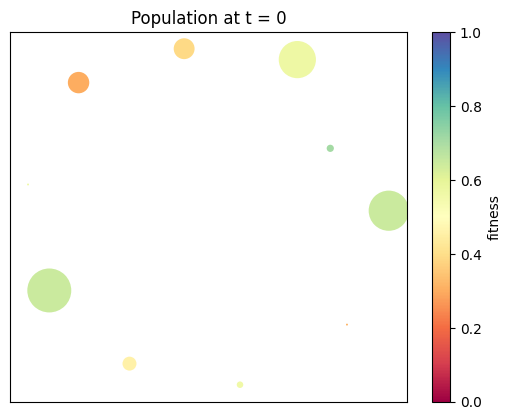

In [38]:
## init results objects    
time_series_freeliving={}
time_series_hostassociated={}

## params grow_and_steady
mutation_rate=1E-4
growth_factor=1.2
steady_state_runtime=50
max_runtime=np.inf
pop_size_thr=1E4
simplify=1
verbose=0
sampling_rate=1

## params run_host_pop_gen
n_worms=1
infection_sym_count=10
tot_host_pop_gen=1
escape_rate=1E-2
n_trials=1
cpus=1

# init tree log-fisher
init_pop_strains=10
is_init_pop_log_fisher=True

if is_init_pop_log_fisher==True:  
    freelivingG=generate_random_fisherlog_pop_unlinked(i=init_pop_strains, seed=666) #n=individuals, i=strains
    freelivingG=nx.relabel_nodes(freelivingG, dict([[i,'0.0.'+str(i)] for i in range(init_pop_strains)]))

SymPop(freelivingG).visualize_pop(view_node_labels=False)

### Get free-living population paramaters

pop_attr=np.array([[node,attr['abundance'],attr['fitness']]for node,attr in freelivingG.nodes(data=True) if attr['abundance']>0])
alleles = pop_attr[:,0]
abundances = np.array(list(map(int,pop_attr[:,1])))
fitnesses = np.array(list(map(float,pop_attr[:,2])))

# Infection

Generator(PCG64)


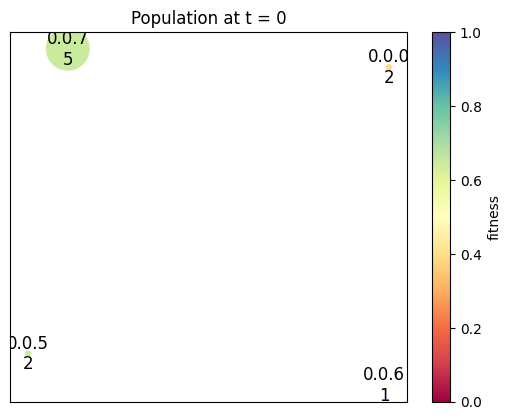

In [95]:
seed=666
rng = np.random.default_rng(seed)
print(rng)

# Infection: set new host and subsample bacteria from free-living population
#subsampleG=subsample_pop(freelivingG,infection_sym_count)
host_pop_gen=1
host_id=1

tot=sum(abundances)
weights=np.multiply(abundances,1/tot)
new_pop_abundances = rng.multinomial(int(infection_sym_count), weights)
new_pop_alleles = [alleles[i] for i in range(len(new_pop_abundances)) if new_pop_abundances[i] > 0]

subsampleG=nx.Graph(freelivingG.subgraph(new_pop_alleles))
adj=[[alleles[i],{'abundance':new_pop_abundances[i],'fitness':fitnesses[i]}] for i in range(len(new_pop_abundances)) if new_pop_abundances[i] > 0]
subsampleG.update(nodes=adj)
initial_intrahost_pop=subsampleG.copy()

new_avail_id=str(host_pop_gen)+'.'+str(host_id)+'.0'

plt.figure()
SymPop(subsampleG).visualize_pop()

# Grow in host

Generator(PCG64)
T_thresh 38.0 T_tot 88.0
init_strains_distribution_expectation [1982, 4956, 1982, 991]
new_strains_total_expectation 89
new_strains_distribution_expectation [75, 3, 10, 1]
new_strains_count 4


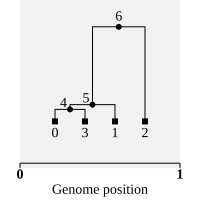

In [97]:
seed=666
rng = np.random.default_rng(seed)
print(rng)

# Grow host
def crp_sample_cluster_sizes(n, theta, rng=None):
    '''Chinese Restaurant Process sampler for Ewens(n, theta).
Returns a list of cluster sizes (allele counts) that sum to n.'''
    rng = np.random.default_rng(rng)
    tables = [] # list of counts per allele
    for i in range(n): # i = number of customers already seated
        total = i
        if not tables:
            tables = [1] # first customer opens first table
            continue
        # Probabilities: join existing table k with prob size_k/(theta+i), or open new with prob theta/(theta+i)
        probs = np.array([c for c in tables] + [theta], dtype=float)
        probs /= (theta + total)
        choice = rng.choice(len(probs), p=probs)
        if choice == len(tables):
            tables.append(1)
        else:
            tables[choice] += 1
    return tables
    
intra_host_selection=False
pop_size_thr=pop_size_thr

G=subsampleG.copy()

pop_attr=np.array([[node,attr['abundance'],attr['fitness']]for node,attr in G.nodes(data=True) if attr['abundance']>0])
alleles = pop_attr[:,0]
abundances = np.array(list(map(int,pop_attr[:,1])))
fitnesses = np.array(list(map(float,pop_attr[:,2])))
N0=sum(abundances)

T_thresh=np.ceil(np.log(pop_size_thr / N0) / np.log(growth_factor) )
T_tot=T_thresh+steady_state_runtime
theta=pop_size_thr*mutation_rate

Prob_no_mutation_over_T=np.power(1 - mutation_rate, T_tot) #The probability of zero mutations over T generations is (1−u)^T

rel_weights=np.multiply(abundances,1/N0*Prob_no_mutation_over_T*pop_size_thr)
init_strains_distribution_expectation = [int(n) for n in rel_weights] # Original strains abundance distribution at the end of the worm's life
new_strains_total_expectation = int(pop_size_thr-sum(init_strains_distribution_expectation)) if sum(init_strains_distribution_expectation)<=pop_size_thr else 0

new_strains_distribution_expectation = crp_sample_cluster_sizes(new_strains_total_expectation, theta, rng=None)
new_strains_count=len(new_strains_distribution_expectation)

print('T_thresh',T_thresh,'T_tot',T_tot)
print('init_strains_distribution_expectation',init_strains_distribution_expectation)
print('new_strains_total_expectation',new_strains_total_expectation)
print('new_strains_distribution_expectation',new_strains_distribution_expectation)
print('new_strains_count',new_strains_count)

### Create a tree 
ts = msprime.sim_ancestry(new_strains_count, random_seed=seed, sequence_length=1, ploidy=1)
ts.draw_svg()


# ########

# new_pop_abundances = np.random.multinomial(int(n * growth_factor), weights)
# tot_new_pop=sum(new_pop_abundances)
# mutated_ind_count=np.random.binomial(int(n), mutation_rate)

# if mutated_ind_count>0:
#     mutated_ind = np.random.multinomial(mutated_ind_count,new_pop_abundances/tot_new_pop)
#     new_pop_abundances=new_pop_abundances-mutated_ind

# adj=[[alleles[i],{'abundance':new_pop_abundances[i],'fitness':fitnesses[i]}] for i in range(len(alleles))]
# G.update(nodes=adj)
        
# if mutated_ind_count>0: # if new alleles have arisen
        
#     # Update pop with new alleles
#     mutated_alleles=np.nonzero(mutated_ind)[0]
#     mutated_alleles_count =len(mutated_alleles)

#     new_avail_prefix='.'.join(new_avail_id.split('.')[0:-1])
#     new_avail_idx=int(new_avail_id.split('.')[-1])
#     new_alleles_ids=['.'.join([new_avail_prefix,str(i)]) for i in range(new_avail_idx,new_avail_idx+mutated_ind_count)]
#     new_avail_id='.'.join([new_avail_prefix,str(new_avail_idx+mutated_ind_count)])
    
#     new_alleles_parent_indices=np.repeat(mutated_alleles, mutated_ind[mutated_alleles]).astype(int)
#     mutated_alleles_parent_fitness=fitnesses[new_alleles_parent_indices]
#     new_alleles_fitnesses=np.sum([mutated_alleles_parent_fitness,np.random.normal(-0.01, 0.01,size=mutated_ind_count)], axis=0) # Assign fitness to the new alleles. The fitness of the new alleles is that of the parent allele +/- a selection coefficient sampled from a normal distribution with mean -0.01 and std 0.01
    
#     new_alleles_nodes=[[new_alleles_ids[i],{'abundance':1,'fitness':new_alleles_fitnesses[i]}] for i in range(len(new_alleles_fitnesses))]
#     new_alleles_edges=np.array([alleles[new_alleles_parent_indices],new_alleles_ids,[{"distance":1}] * len(new_alleles_ids)]).transpose()

#     G.update(edges=new_alleles_edges, nodes=new_alleles_nodes)

Generator(PCG64)
probability_of_exactly_k_distinct_founders [0.0001, 0.0135, 0.18, 0.504, 0.3024, 0.0, 0.0, 0.0, 0.0, 0.0]
distinct_founder_cell_count 3
infection_strains_relab [0.4 0.2 0.2 0.2]
init_strain_indices [2 1 3]
T= 0.16011156488613046
roots [1, 3, 6]


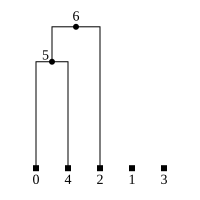

In [53]:
from scipy.special import stirling2
from math import perm

seed=666
rng = np.random.default_rng(None)
print(rng)
# S = [stirling2(new_strains_count, n, exact=True) for n in range(1,infection_sym_count+1)]
# falling_factorial=[perm(infection_sym_count, n) for n in range(1,infection_sym_count+1) ]
# power=[infection_sym_count**new_strains_count for n in range(1,infection_sym_count+1)]

probability_of_exactly_k_distinct_founders=[(stirling2(new_strains_count, n, exact=True))*(perm(infection_sym_count, n))*1/(infection_sym_count**new_strains_count) for n in range(1,infection_sym_count+1)]



T=None
while T == None:
    
    ## Sample from that probability distribution and cut the tree at n lineages dictated by the array index
    distinct_founder_cell_count=rng.choice(range(1,infection_sym_count+1),p=probability_of_exactly_k_distinct_founders)
    
    print('probability_of_exactly_k_distinct_founders',probability_of_exactly_k_distinct_founders)
    print('distinct_founder_cell_count',distinct_founder_cell_count)

    # attribute each new strain to the strain type of a founder cell, with prob dictated by their relative abundance
    infection_strains_relab=np.multiply(abundances,1/N0)
    print('infection_strains_relab',infection_strains_relab)
    init_strain_indices = rng.choice(len(infection_strains_relab), size=distinct_founder_cell_count, p=infection_strains_relab)
    print('init_strain_indices',init_strain_indices)


    if distinct_founder_cell_count == new_strains_count:
        print('each new strain comes from a different founder cell')
        # each new strain comes from a different founder cell
        
    tree = ts.first() # pick a specific tree
    T=find_T_with_k_lineages_in_binary_tree(tree, k=distinct_founder_cell_count,eps=1e-9)

print('T=',T)


ts2=cut_tree_sequence_above_time(ts,T)

# attribute a strain to each subtree according to the initial strain probability distribution
ts2.first().roots

print('roots', [root for root in ts2.first().roots])
# combine cuttings per strain if sampled
# add fitnesses
# Add new tree (combined cuttings) to that strain in the network
# reset the abundances


ts2.first().draw_svg()


In [54]:
ts2.tables.edges.child

array([0, 4, 2, 5], dtype=int32)

In [55]:
ts2.tables.nodes.flags

array([1, 1, 1, 1, 1, 0, 0], dtype=uint32)

In [56]:
ts2.tables.nodes[ts2.tables.nodes.flags==1]

id,time,flags,population,individual,metadata
0,0,1,0,0,
1,0,1,0,1,
2,0,1,0,2,
3,0,1,0,3,
4,0,1,0,4,


In [57]:
ts2.tables.nodes.num_rows

num_nodes = ts2.tables.nodes.num_rows
has_parent = np.zeros(num_nodes, dtype=bool)
has_child = np.zeros(num_nodes, dtype=bool)

child_col = ts2.tables.edges.child
parent_col = ts2.tables.edges.parent
if len(child_col) > 0:
    has_parent[np.asarray(child_col, dtype=int)] = True
    has_child[np.asarray(parent_col, dtype=int)] = True

targets = np.where(~has_parent & has_child)[0]  
[int(i) for i in np.where(~has_parent & has_child)[0]]

[6]

root alleles ['0.0.6' '0.0.5' '0.0.0']
root fitnesses [0.85544397 0.96892652 0.5822414 ]
leaves_abundances [67, 11, 7, 4, 1]
new_roots_list [6, 7, 8]
root_ids ['0.0.6' '0.0.5' '0.0.0']


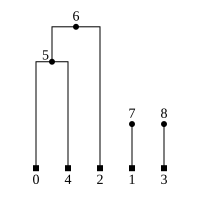

In [64]:
def add_roots_abundances_and_propagate_fitnesses(
    ts,
    root_fitnesses=None, # length = number of original roots, ordered by root child ID ascending
    root_ids=None,
    leaf_abundances=None, # length = number of leaves after adding roots, ordered by leaf node ID ascending
    delta_time=0.05,
    s_mean=-0.1,
    s_std=0.1,
    seed=None,
    clamp_s=True
    ):

    def _pack_metadata_bytes(rows):
        """
        rows: list of bytes (one per row)
        returns: (packed_bytes, offsets_array)
        """
        import numpy as np
        n = len(rows)
        offsets = np.zeros(n + 1, dtype=np.uint32)
        parts = []
        total = 0
        for i, b in enumerate(rows):
            if b is None:
                b = b""
            parts.append(b)
            total += len(b)
            offsets[i + 1] = total
        return b"".join(parts), offsets

    
    tables = ts.tables.copy()
    
    # Metadata schemas
    tables.edges.metadata_schema = tskit.MetadataSchema({
        "codec": "json",
        "schema": {
            "type": "object",
            "properties": {"distance": {"type": "integer"}},
            "additionalProperties": False
        }
    })
    tables.nodes.metadata_schema = tskit.MetadataSchema({
        "codec": "json",
        "schema": {
            "type": "object",
            "properties": {
                "fitness": {"type": "float"},
                "abundance": {"type": "integer"},
                "mutation_count": {"type": "integer"},
                "strain_id" : {"type": "str"}
            },
            "additionalProperties": False
        }
    })
    
    # Original roots (nodes with no parent)
    num_nodes = tables.nodes.num_rows
    has_parent = np.zeros(num_nodes, dtype=bool)
    has_child = np.zeros(num_nodes, dtype=bool)

    child_col = tables.edges.child
    parent_col = tables.edges.parent
    if len(child_col) > 0:
        has_parent[np.asarray(child_col, dtype=int)] = True
        has_child[np.asarray(parent_col, dtype=int)] = True
    
    targets = np.where(~has_parent & ~has_child)[0]  

    seq_len = ts.sequence_length
    node_time = tables.nodes.time
    
    # Add a new parent above each singleton root
    
    new_root_pairs = []
    for u in targets:
        t_parent = float(node_time[u]) + float(delta_time)
        pop = tables.nodes.population[u]
        parent_id = tables.nodes.add_row(
            flags=0,
            time=t_parent,
            population=pop,
            individual=tskit.NULL,
            metadata={"abundance":0, "fitness":None, "strain_id": "TBD"} # don’t pass raw bytes when using JSON metadata schema
        )
        tables.edges.add_row(
            left=0.0,
            right=seq_len,
            parent=parent_id,
            child=u,
            metadata={"distance":1}
        )
        new_root_pairs.append((parent_id, u))
    
    tables.sort()
    
    # New roots
    new_roots_list = list(map(int,np.array(range(tables.nodes.num_rows))[tables.nodes.flags==0]))
    new_roots_list = [root for root in new_roots_list if root not in tables.edges.child]
    new_leaves_list = list(map(int,np.array(range(tables.nodes.num_rows))[tables.nodes.flags==1]))
    
    # leaf_abundances validation and mapping
    if leaf_abundances is not None:
        leaf_abundances = list(leaf_abundances)
        if len(leaf_abundances) != len(new_leaves_list):
            raise ValueError(
                f"leaf_abundances length {len(leaf_abundances)} != number of leaves {len(new_leaves_list)}. "
                f"Leaves (by node ID): {new_leaves_list}"
            )
        leaf_abund_map = {leaf: int(a) for leaf, a in zip(new_leaves_list, leaf_abundances)}
    else:
        leaf_abund_map = None


    print('new_roots_list',new_roots_list)
    print('root_ids',root_ids)
    root_id_map = {root: str(a) for root, a in zip(new_roots_list,root_ids)}
    rng = np.random.default_rng(seed)
    NODE_IS_SAMPLE = tskit.NODE_IS_SAMPLE
    
    # Build adjacency
    N = tables.nodes.num_rows
    children = [[] for _ in range(N)]
    for e in tables.edges:
        children[e.parent].append(e.child)
            
    node_meta = [None] * N
    
    def dfs(u, fitness, mut_count):
    
        # Leaf abundance base
        if len(children[u]) == 0:
            if leaf_abund_map is not None:
                total_abund = leaf_abund_map.get(u, 0)
            else:
                total_abund = 0
        else:
            total_abund = 0
    
        node_meta[u] = {
            "fitness": float(fitness),
            "mutation_count": int(mut_count),
            "abundance": leaf_abund_map.get(u, 0),
            "strain_id": root_id_map.get(u, 0)
        }
    
        for v in children[u]:
            s = rng.normal(loc=s_mean, scale=s_std)
            if clamp_s and s < -0.99:
                s = -0.99
            child_fitness = fitness * (1.0 + s)
            dfs(v, child_fitness, mut_count + 1)
            # total_abund = node_meta[v]["abundance"]
    
        node_meta[u]["abundance"] = int(total_abund)
    
    # Start DFS from each new root with its initial fitness
    for r, f0 in zip(new_roots_list, root_fitnesses):
        dfs(r, fitness=float(f0), mut_count=0)
    
    # Set node metadata: prefer packset_metadata, fallback to set_metadata
    node_metadata_rows = [json.dumps(d).encode("utf-8") for d in node_meta]
    if hasattr(tables.nodes, "packset_metadata"):
        tables.nodes.packset_metadata(node_metadata_rows)
    else:
        node_metadata, node_metadata_offset = _pack_metadata_bytes(node_metadata_rows)
        tables.nodes.set_metadata(node_metadata, node_metadata_offset)
    
    # Set edge metadata: distance=1 on every edge
    edge_metadata_rows = [json.dumps({"distance": 1}).encode("utf-8") for _ in range(tables.edges.num_rows)]
    if hasattr(tables.edges, "packset_metadata"):
        tables.edges.packset_metadata(edge_metadata_rows)
    else:
        edge_metadata, edge_metadata_offset = _pack_metadata_bytes(edge_metadata_rows)
        tables.edges.set_metadata(edge_metadata, edge_metadata_offset)
    
    # tables.sort()
    return tables.tree_sequence()



print('root alleles',alleles[init_strain_indices])
print('root fitnesses',fitnesses[init_strain_indices])
print('leaves_abundances',new_strains_distribution_expectation)
ts3=add_roots_abundances_and_propagate_fitnesses(ts2,root_fitnesses=fitnesses[init_strain_indices],root_ids=alleles[init_strain_indices], leaf_abundances=new_strains_distribution_expectation)
ts3.first().draw_svg()

In [65]:
ts3.tables.edges.child

array([1, 3, 0, 4, 2, 5], dtype=int32)

╔══╤════╤═════╤══════╤═════╤═══════════════╗
║id│left│right│parent│child│metadata       ║
╠══╪════╪═════╪══════╪═════╪═══════════════╣
║0 │   0│    1│     7│    1│{'distance': 1}║
║1 │   0│    1│     8│    3│{'distance': 1}║
║2 │   0│    1│     5│    0│{'distance': 1}║
║3 │   0│    1│     5│    4│{'distance': 1}║
║4 │   0│    1│     6│    2│{'distance': 1}║
║5 │   0│    1│     6│    5│{'distance': 1}║
╚══╧════╧═════╧══════╧═════╧═══════════════╝

╔══╤══════════╤═════╤══════════╤══════════╤════════════════════════════════════════╗
║id│time      │flags│population│individual│metadata                                ║
╠══╪══════════╪═════╪══════════╪══════════╪════════════════════════════════════════╣
║0 │0.00000000│    1│         0│         0│{'fitness': 0.7161027787231009, 'muta...║
║1 │0.00000000│    1│         0│         1│{'fitness': 0.9699855780231906, 'muta...║
║2 │0.00000000│    1│         0│         2│{'fitness': 0.7118035529859371, 'muta...║
║3 │0.00000000│    1│         0│       

[{'fitness': 0.7161027787231009,
  'mutation_count': 2,
  'abundance': 67,
  'strain_id': 0},
 {'fitness': 0.9699855780231906,
  'mutation_count': 1,
  'abundance': 11,
  'strain_id': 0},
 {'fitness': 0.7118035529859371,
  'mutation_count': 1,
  'abundance': 7,
  'strain_id': 0},
 {'fitness': 0.49553965612325024,
  'mutation_count': 1,
  'abundance': 4,
  'strain_id': 0},
 {'fitness': 0.6443791841915719,
  'mutation_count': 2,
  'abundance': 1,
  'strain_id': 0},
 {'fitness': 0.7699830194429577,
  'mutation_count': 1,
  'abundance': 0,
  'strain_id': 0},
 {'fitness': 0.8554439726820243,
  'mutation_count': 0,
  'abundance': 0,
  'strain_id': '0.0.6'},
 {'fitness': 0.9689265237329896,
  'mutation_count': 0,
  'abundance': 0,
  'strain_id': '0.0.5'},
 {'fitness': 0.5822414027981625,
  'mutation_count': 0,
  'abundance': 0,
  'strain_id': '0.0.0'}]

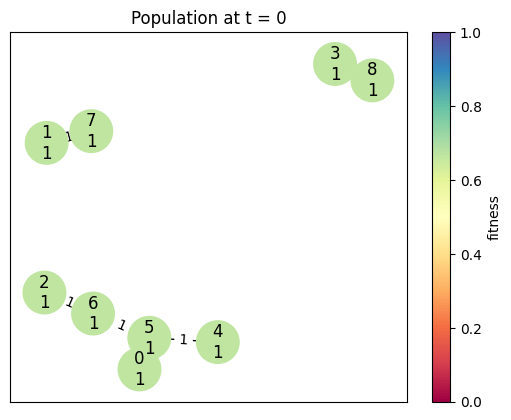

In [66]:
edges=ts3.tables.edges
nodes=ts3.tables.nodes

print(edges)
print(nodes)
node_meta = [ts3.node(u).metadata for u in range(ts3.num_nodes)]
node_meta = [dict(m) if m is not None else {} for m in node_meta]

G = nx.from_pandas_edgelist(
    pd.DataFrame({'source': edges.parent, 'target': edges.child, 'left': edges.left, 'right': edges.right,'distance':[1 for d in edges]}),
    edge_attr=True,
    create_using=nx.Graph
)

nx.set_node_attributes(G, {i: {'abundance':1, 'fitness': 1} for i in range(len(nodes))})

SymPop(G).visualize_pop()
node_meta


Graph with 9 nodes and 6 edges


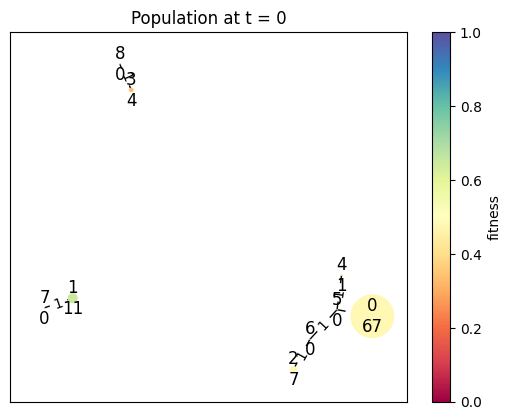

In [67]:
G=tstree_to_networkx_graph(ts3)
print(G)
SymPop(G).visualize_pop(abundance_threshold=0,show_empty=True)


{7: '0.0.5', 1: '0.1.0', 8: '0.0.0', 3: '0.1.1', 5: '0.1.2', 0: '0.1.3', 4: '0.1.4', 6: '0.0.6', 2: '0.1.5'}
['0.0.5', '0.1.0', '0.0.0', '0.1.1', '0.1.2', '0.1.3', '0.1.4', '0.0.6', '0.1.5']


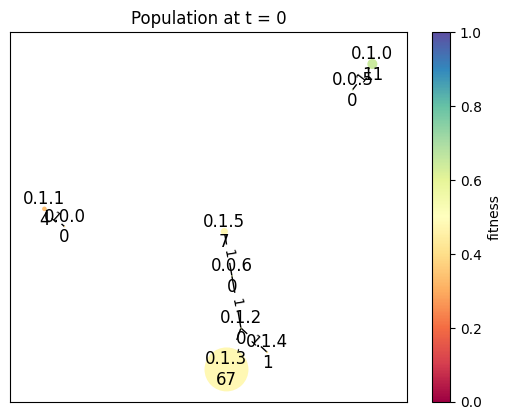

In [68]:
def tstree_to_networkx_graph_with_strain_ids(ts,new_avail_id):
    edges=ts.tables.edges
    nodes=ts.tables.nodes

    G = nx.from_pandas_edgelist(
        pd.DataFrame({'source': edges.parent, 'target': edges.child, 'left': edges.left, 'right': edges.right,'distance':[d.metadata["distance"] for d in edges]}),
        edge_attr=True,
        create_using=nx.Graph
    )
    nx.set_node_attributes(G, {i: {'abundance':nodes[i].metadata["abundance"], 'fitness': nodes[i].metadata["fitness"], 'strain_id': nodes[i].metadata["strain_id"]} for i in range(len(nodes))})

    #### relabel nodes
    i=0
    mylabel_dic={}
    new_avail_prefix='.'.join(new_avail_id.split('.')[0:-1])
    for node,attr in G.nodes(data=True):
        if attr['strain_id']==0:
            new_avail_id='.'.join([new_avail_prefix,str(i)])
            i+=1
            mylabel_dic[node]=new_avail_id
        else:
            mylabel_dic[node]=attr['strain_id']
            
    G=nx.relabel_nodes(G,mylabel_dic)
    return(G)



G=tstree_to_networkx_graph_with_strain_ids(ts3,'0.1.0')
print(G.nodes)
SymPop(G).visualize_pop(abundance_threshold=0,show_empty=True)

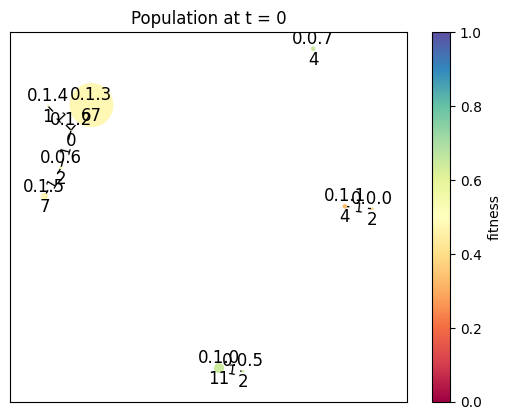

In [69]:
newG=merge_graphs([subsampleG,G])
SymPop(newG).visualize_pop(abundance_threshold=0,show_empty=True)


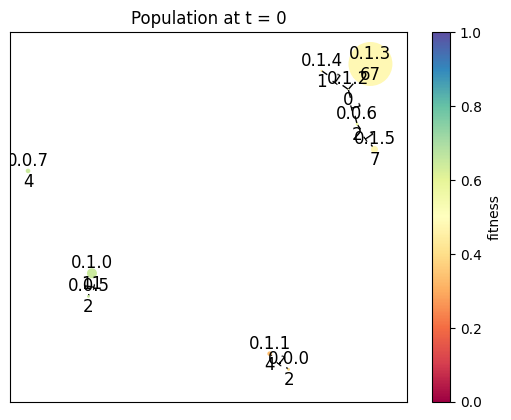

In [71]:

SymPop(remove_empty_leaves_and_rescale_edges(newG)).visualize_pop(abundance_threshold=0,show_empty=True)


# Putting it all together

In [ ]:
## init results objects    
time_series_freeliving={}
time_series_hostassociated={}

## params grow_and_steady
mutation_rate=1E-4
growth_factor=1.2
steady_state_runtime=50
max_runtime=np.inf
pop_size_thr=1E4
simplify=1
verbose=0
sampling_rate=1

## params run_host_pop_gen
n_worms=1
infection_sym_count=10
tot_host_pop_gen=1
escape_rate=1E-2
n_trials=1
cpus=1

# init tree log-fisher
init_pop_strains=10
is_init_pop_log_fisher=True

if is_init_pop_log_fisher==True:  
    freelivingG=generate_random_fisherlog_pop_unlinked(i=init_pop_strains, seed=666) #n=individuals, i=strains
    freelivingG=nx.relabel_nodes(freelivingG, dict([[i,'0.0.'+str(i)] for i in range(init_pop_strains)]))

SymPop(freelivingG).visualize_pop(view_node_labels=False)

### Get free-living population paramaters

pop_attr=np.array([[node,attr['abundance'],attr['fitness']]for node,attr in freelivingG.nodes(data=True) if attr['abundance']>0])
alleles = pop_attr[:,0]
abundances = np.array(list(map(int,pop_attr[:,1])))
fitnesses = np.array(list(map(float,pop_attr[:,2])))

host_pop_gen=1
host_id=1

In [93]:
from project_package.run_model import *


############


args=[{'freelivingG':freelivingG,'alleles':alleles,'abundances':abundances,'fitnesses':fitnesses,
           'host_pop_gen':host_pop_gen, 'host_id':host_id,
           'infection_sym_count':infection_sym_count,
           'mutation_rate':mutation_rate, 'growth_factor':growth_factor,'steady_state_runtime':steady_state_runtime,
           'pop_size_thr':pop_size_thr,'escape_rate':escape_rate, 'seed':None} for host_id in range(n_worms)]


initial_intrahost_pop,final_intrahost_pop,final_escapees_pop=grow_from_freeliving_direct(args[0])


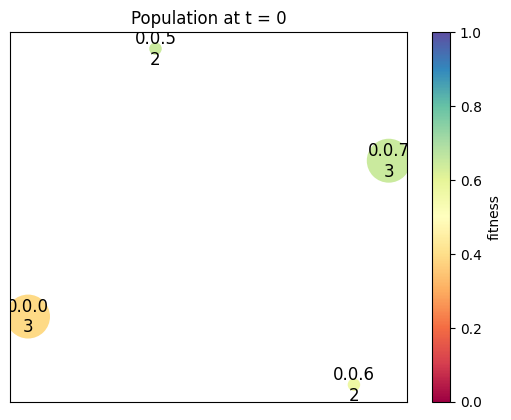

In [84]:
SymPop(initial_intrahost_pop).visualize_pop()

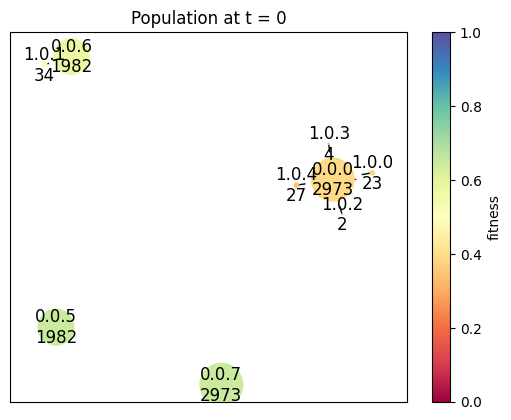

In [85]:
SymPop(final_intrahost_pop).visualize_pop()

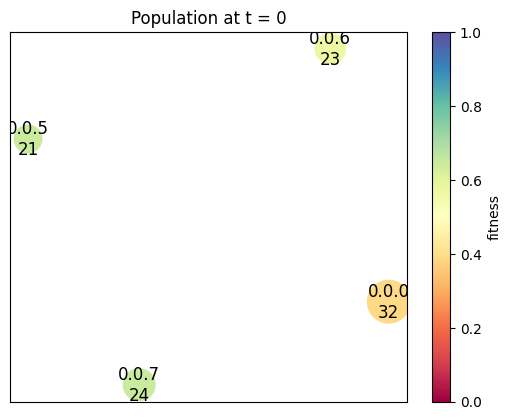

In [86]:
SymPop(final_escapees_pop).visualize_pop()